In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

### load dataset

In [2]:
df = pd.read_csv('solar_data.csv')
df.head()

,customer_id,tenure,total_amount_paid,outstanding_balance,repayment_rate,missed_payments,gender,birth_year,age,payment_3m,...,outbound_calls,received_calls,unanswered_calls,ivr_calls,csat_calls,total_talk_minutes,repossession_tickets,followup_tickets,complaint_tickets,churn
0,GBEFDJG,1413,426800,365200,54,470,male,1992,33,39600.0,...,30,1,1,2,0,20.7500,0.0,0,0,1
1,GBAGFBB,1398,610045,181955,77,253,male,1968,57,53000.0,...,44,1,1,0,0,37.8833,0.0,0,0,1
2,GEJGIFG,1201,177300,494700,26,727,male,1992,34,53300.0,...,29,1,2,0,0,21.5166,0.0,0,0,1
3,GEEDDAC,1251,598600,192246,76,246,male,1977,48,85400.0,...,75,2,5,2,0,128.7166,0.0,0,2,1
4,GBBDGBC,1421,143550,450450,24,751,male,1949,76,32250.0,...,2,0,0,0,0,1.0833,1.0,0,0,1


In [6]:
df.shape

(27000, 26)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27000 entries, 0 to 26999
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           27000 non-null  object 
 1   tenure                27000 non-null  int64  
 2   total_amount_paid     27000 non-null  int64  
 3   outstanding_balance   27000 non-null  int64  
 4   repayment_rate        27000 non-null  int64  
 5   missed_payments       27000 non-null  int64  
 6   gender                27000 non-null  object 
 7   birth_year            27000 non-null  int64  
 8   age                   27000 non-null  int64  
 9   payment_3m            27000 non-null  float64
 10  avg_payment_3m        27000 non-null  float64
 11  payment_trend_3m      27000 non-null  float64
 12  volatility_3m         27000 non-null  float64
 13  last_paid_month       27000 non-null  object 
 14  last_paid_amount      27000 non-null  float64
 15  total_calls        

In [18]:
solar_data.describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,26575.0,1259.808203,208.428706,44.00,1227.000000,1284.000000,1362.000000,2.970000e+03
total_amount_paid,26575.0,409898.425851,559111.729702,2800.00,174955.000000,309200.000000,479400.000000,6.933659e+06
outstanding_balance,26575.0,374087.236275,323401.577937,0.00,185150.000000,351500.000000,490100.000000,5.823318e+06
repayment_rate,26575.0,49.479737,26.989558,1.00,27.000000,47.000000,73.000000,1.000000e+02
missed_payments,26575.0,489.579492,273.048077,0.00,260.000000,515.000000,718.000000,9.880000e+02
birth_year,26575.0,1985.556990,13.280826,1900.00,1977.000000,1988.000000,1995.000000,2.082000e+03
age,26575.0,39.950894,13.288233,-57.00,30.000000,38.000000,48.000000,1.260000e+02
payment_3m,26575.0,67310.840387,85718.866355,100.00,37500.000000,52850.000000,70900.000000,3.428000e+06
avg_payment_3m,26575.0,7554.205914,31669.087510,100.00,1765.222817,3536.842105,6785.164835,3.200000e+06
payment_trend_3m,26575.0,15714.768120,39050.465372,0.00,2400.000000,4800.000000,27800.000000,3.372000e+06


In [19]:
solar_data.describe(include='object').T

,count,unique,top,freq
customer_id,26575,26575,GBEFDJG,1
gender,26575,2,male,17399
last_paid_month,26575,49,4/1/23 0:00,21678


### Check missing values

In [12]:
solar_data.isnull().sum()

customer_id             0
tenure                  0
total_amount_paid       0
outstanding_balance     0
repayment_rate          0
missed_payments         0
gender                  0
birth_year              0
age                     0
payment_3m              0
avg_payment_3m          0
payment_trend_3m        0
volatility_3m           0
last_paid_month         0
last_paid_amount        0
total_calls             0
outbound_calls          0
received_calls          0
unanswered_calls        0
ivr_calls               0
csat_calls              0
total_talk_minutes      0
repossession_tickets    1
followup_tickets        0
complaint_tickets       0
churn                   0
dtype: int64

### Target variable exploration

In [21]:
solar_data['churn'].value_counts()

churn
1    14963
0    11612
Name: count, dtype: int64

In [22]:
solar_data['churn'].value_counts(normalize=True)*100

churn
1    56.304798
0    43.695202
Name: proportion, dtype: float64

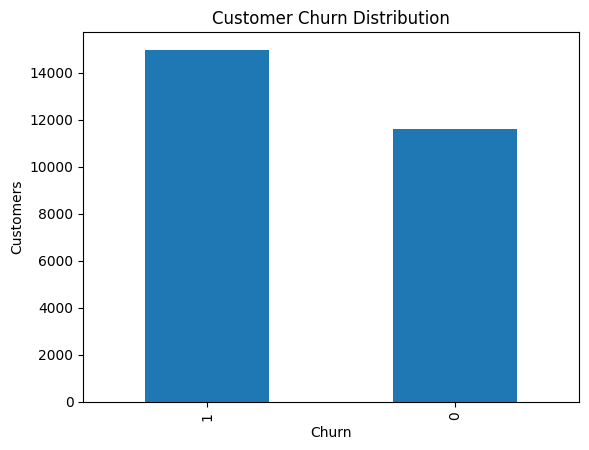

In [23]:
solar_data['churn'].value_counts().plot(
    kind='bar',
    title='Customer Churn Distribution'
)

plt.xlabel("Churn")
plt.ylabel("Customers")
plt.show()

### Age data quality check

In [24]:
solar_data['gender'].value_counts()

gender
male      17399
female     9176
Name: count, dtype: int64

**Insight:**

- The dataset is male-dominated.
- Male customers represent approximately 65.5% of records, while females represent 34.5%.

In [25]:
solar_data['age'].describe()

count    26575.000000
mean        39.950894
std         13.288233
min        -57.000000
25%         30.000000
50%         38.000000
75%         48.000000
max        126.000000
Name: age, dtype: float64

**Data quality issues:** 

You have invalid age values:

- Negative ages (-57) - impossible, likely data entry errors.
- Very high ages (126) - possible outlier or incorrect entry.
- 425 missing ages - need handling.

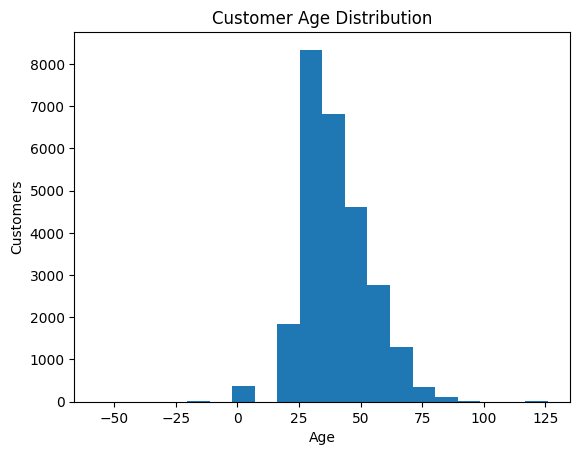

In [26]:
plt.hist(
    solar_data['age'],
    bins=20
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Customers")
plt.show()

In [28]:
# fix age issue
solar_data[(solar_data['age'] < 0) | (solar_data['age'] > 100)].shape

(27, 26)

In [32]:
solar_data.loc[(solar_data['age'] < 0) | (solar_data['age'] > 100), 'age'] = np.nan
solar_data.loc[solar_data['age'] < 20, 'age'] = np.nan

In [33]:
solar_data['age'].describe()

count    26142.000000
mean        40.495754
std         12.384913
min         20.000000
25%         31.000000
50%         38.000000
75%         48.000000
max         97.000000
Name: age, dtype: float64

### Compare demographics with churn

In [35]:
pd.crosstab(
    solar_data['gender'],
    solar_data['churn'],
    normalize='index'
)*100

churn,0,1
gender,,
female,44.899738,55.100262
male,43.059946,56.940054


**Key insights:**
- Churn is high across both genders, with more than half of customers leaving.
- Male customers have a slightly higher churn rate (56.9%) compared to female customers (55.1%).
- The difference is small (1.8 percentage points), suggesting gender alone is unlikely to be a strong predictor of churn.

### Age vs churn

In [36]:
solar_data.groupby('churn')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,11397.0,41.060104,12.355383,20.0,31.0,39.0,49.0,96.0
1,14745.0,40.059546,12.390507,20.0,30.0,37.0,48.0,97.0


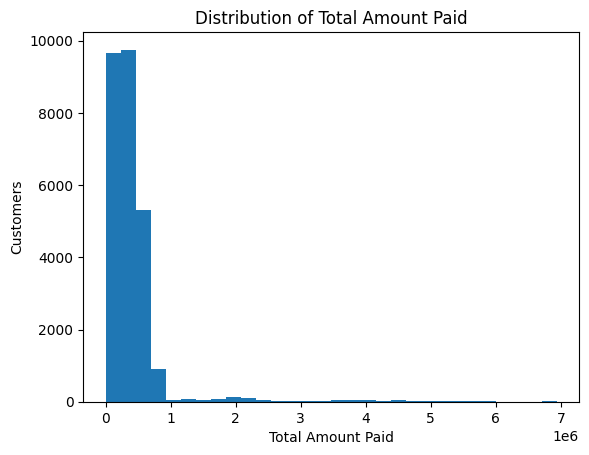

In [38]:


plt.hist(
    solar_data['total_amount_paid'],
    bins=30
)

plt.title("Distribution of Total Amount Paid")
plt.xlabel("Total Amount Paid")
plt.ylabel("Customers")
plt.show()

In [39]:
solar_data.groupby('churn')['total_amount_paid'].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,11612.0,627877.522305,774479.823398,8000.0,325237.5,460535.0,585377.5,6933659.0
1,14963.0,240736.274678,155711.546807,2800.0,120250.0,212600.0,333433.0,1497000.0


### Outstanding Balance

In [40]:
solar_data['outstanding_balance'].describe()

count    2.657500e+04
mean     3.740872e+05
std      3.234016e+05
min      0.000000e+00
25%      1.851500e+05
50%      3.515000e+05
75%      4.901000e+05
max      5.823318e+06
Name: outstanding_balance, dtype: float64

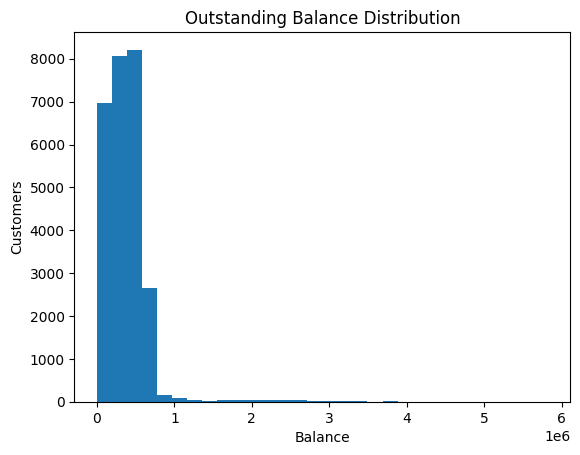

In [41]:
plt.hist(
    solar_data['outstanding_balance'],
    bins=30
)

plt.title("Outstanding Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Customers")
plt.show()

In [42]:
solar_data.groupby('churn')['outstanding_balance'].mean()

churn
0    317241.409060
1    418202.303148
Name: outstanding_balance, dtype: float64

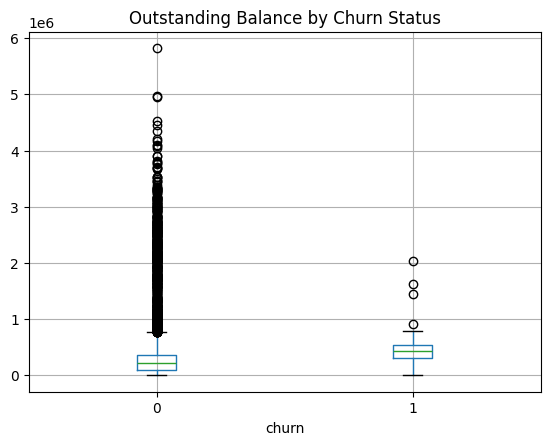

In [43]:
solar_data.boxplot(
    column='outstanding_balance',
    by='churn'
)

plt.title("Outstanding Balance by Churn Status")
plt.suptitle("")
plt.show()

### Repayment Rate

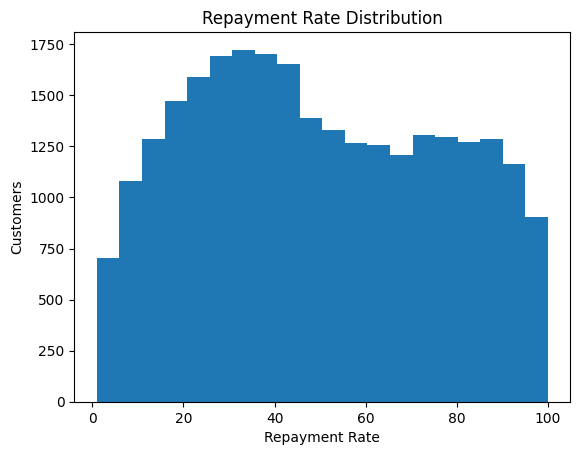

In [44]:
plt.hist(
    solar_data['repayment_rate'],
    bins=20
)

plt.title("Repayment Rate Distribution")
plt.xlabel("Repayment Rate")
plt.ylabel("Customers")
plt.show()

In [45]:
solar_data.groupby('churn')['repayment_rate'].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,11612.0,66.108853,22.674148,3.0,49.0,70.0,85.0,100.0
1,14963.0,36.574751,22.663650,1.0,19.0,33.0,50.0,100.0


### Missed Payments

In [46]:
solar_data['missed_payments'].value_counts().sort_index()

missed_payments
0      1209
1        11
2         5
3         4
4         6
       ... 
983       1
984       1
985       2
986       2
988       2
Name: count, Length: 988, dtype: int64

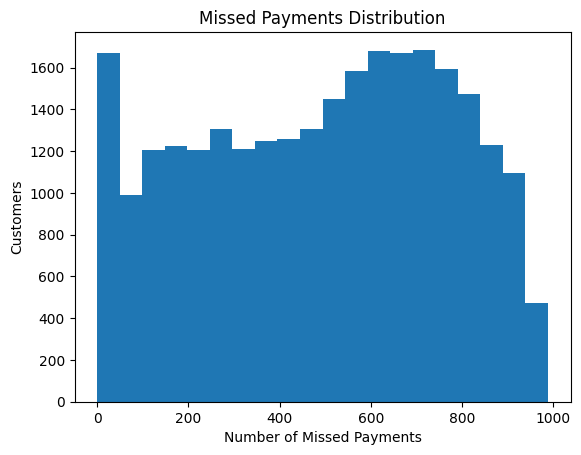

In [47]:
plt.hist(
    solar_data['missed_payments'],
    bins=20
)

plt.title("Missed Payments Distribution")
plt.xlabel("Number of Missed Payments")
plt.ylabel("Customers")
plt.show()

In [48]:
solar_data.groupby('churn')['missed_payments'].mean()

churn
0    308.038925
1    630.463610
Name: missed_payments, dtype: float64

### Recent Payment Behaviour

In [49]:
solar_data[
    ['payment_3m',
     'avg_payment_3m',
     'payment_trend_3m',
     'volatility_3m']
].describe().T

,count,mean,std,min,25%,50%,75%,max
payment_3m,26575.0,67310.840387,85718.866355,100.0,37500.000000,52850.000000,70900.000000,3428000.0
avg_payment_3m,26575.0,7554.205914,31669.087510,100.0,1765.222817,3536.842105,6785.164835,3200000.0
payment_trend_3m,26575.0,15714.768120,39050.465372,0.0,2400.000000,4800.000000,27800.000000,3372000.0
volatility_3m,26575.0,4859.563816,16012.872783,0.0,639.526452,1571.623365,7067.212702,1686000.0


In [50]:
financial_features = [
    'payment_3m',
    'avg_payment_3m',
    'payment_trend_3m',
    'volatility_3m'
]

solar_data.groupby('churn')[financial_features].mean()

,payment_3m,avg_payment_3m,payment_trend_3m,volatility_3m
churn,,,,
0,84870.927685,9803.406013,19275.090327,6078.322358
1,53683.377063,5808.719611,12951.788672,3913.749194


### Correlation with churn

In [52]:
financial_corr = solar_data[
    [
        'total_amount_paid',
        'outstanding_balance',
        'repayment_rate',
        'missed_payments',
        'payment_3m',
        'avg_payment_3m',
        'payment_trend_3m',
        'volatility_3m',
        'churn'
    ]
].corr()

financial_corr['churn'].sort_values()

repayment_rate        -0.542782
total_amount_paid     -0.343454
payment_3m            -0.180469
payment_trend_3m      -0.080318
volatility_3m         -0.067050
avg_payment_3m        -0.062567
outstanding_balance    0.154849
missed_payments        0.585716
churn                  1.000000
Name: churn, dtype: float64

## Data Preparation for Modelling

In [53]:
# Create a modelling copy
model_data = solar_data.copy()

#### Handle missing values

In [54]:
model_data.isnull().sum()

customer_id               0
tenure                    0
total_amount_paid         0
outstanding_balance       0
repayment_rate            0
missed_payments           0
gender                    0
birth_year                0
age                     433
payment_3m                0
avg_payment_3m            0
payment_trend_3m          0
volatility_3m             0
last_paid_month           0
last_paid_amount          0
total_calls               0
outbound_calls            0
received_calls            0
unanswered_calls          0
ivr_calls                 0
csat_calls                0
total_talk_minutes        0
repossession_tickets      1
followup_tickets          0
complaint_tickets         0
churn                     0
dtype: int64

In [59]:
model_data['age'] = model_data['age'].fillna(
    model_data['age'].median()
)

In [61]:
model_data[model_data['repossession_tickets'].isna()]

,customer_id,tenure,total_amount_paid,outstanding_balance,repayment_rate,missed_payments,gender,birth_year,age,payment_3m,...,outbound_calls,received_calls,unanswered_calls,ivr_calls,csat_calls,total_talk_minutes,repossession_tickets,followup_tickets,complaint_tickets,churn
25446,GBCIFGG,1357,83600,708400,11,887,female,1988,38.0,56000.0,...,0,0,0,0,0,0.0,NaN,0,0,0


In [62]:
model_data['repossession_tickets'] = model_data['repossession_tickets'].fillna(0)

In [68]:
model_data.dtypes

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


customer_id              object
tenure                    int64
total_amount_paid         int64
outstanding_balance       int64
repayment_rate            int64
missed_payments           int64
gender                   object
birth_year                int64
age                     float64
payment_3m              float64
avg_payment_3m          float64
payment_trend_3m        float64
volatility_3m           float64
last_paid_month          object
last_paid_amount        float64
total_calls               int64
outbound_calls            int64
received_calls            int64
unanswered_calls          int64
ivr_calls                 int64
csat_calls                int64
total_talk_minutes      float64
repossession_tickets    float64
followup_tickets          int64
complaint_tickets         int64
churn                     int64
dtype: object

## Encode categorical variables

In [67]:
model_data.select_dtypes(include='object').columns

Index(['customer_id', 'gender', 'last_paid_month'], dtype='object')

In [69]:
model_data = pd.get_dummies(
    model_data,
    columns=['gender'],
    drop_first=True
)

### Feature Engineering

In [71]:
# Outstanding balance pressure
model_data['balance_ratio'] = (
    model_data['outstanding_balance'] /
    (model_data['total_amount_paid'] + 1)
)

#### Payment reliability

In [72]:
model_data['payment_reliability'] = (
    model_data['repayment_rate'] / 
    (model_data['missed_payments'] + 1)
)

### Engagement features

#### Unanswered call rate

In [73]:
model_data['unanswered_rate'] = (
    model_data['unanswered_calls'] /
    (model_data['total_calls'] + 1)
)

#### Complaint flag

In [74]:
model_data['complaint_flag'] = (
    model_data['complaint_tickets'] > 0
).astype(int)

#### Repossession flag

In [75]:
model_data['repossession_flag'] = (
    model_data['repossession_tickets'] > 0
).astype(int)

### Check final dataset

In [76]:
model_data.shape

(26575, 31)

### Feature Scaling

In [90]:
X = model_data.drop(
    ['churn', 'customer_id', 'last_paid_month'],
    axis=1
)

y = model_data['churn']

In [88]:
## Split

In [91]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [92]:
## Confirm no text columns remain
X_train.select_dtypes(include='object').columns

Index([], dtype='object')

The last_paid_month variable was excluded from modelling because the dataset contained sufficient payment behaviour variables capturing recent payment activity, while the month label itself provided limited predictive value without additional temporal transformation.

In [106]:
import pandas as pd

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

### Initialize the model

### Train the model

In [107]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### Make predictions

In [108]:
models = {

    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric='logloss'
    )
}

In [109]:
results = []

for name, model in models.items():

    print(f"Training {name}...")
    
    # Logistic Regression uses scaled features
    if name == "Logistic Regression":
        model.fit(
            X_train_scaled,
            y_train
        )

        y_pred = model.predict(
            X_test_scaled
        )

        y_prob = model.predict_proba(
            X_test_scaled
        )[:,1]

    else:
        model.fit(
            X_train,
            y_train
        )

        y_pred = model.predict(
            X_test
        )

        y_prob = model.predict_proba(
            X_test
        )[:,1]


    results.append({

        "Model": name,

        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),

        "Precision": precision_score(
            y_test,
            y_pred
        ),

        "Recall": recall_score(
            y_test,
            y_pred
        ),

        "F1 Score": f1_score(
            y_test,
            y_pred
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob
        )
    })

Training Logistic Regression...
Training Random Forest...
Training XGBoost...


In [112]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,XGBoost,0.849483,0.902385,0.821584,0.860091,0.923702
0,Logistic Regression,0.839135,0.865595,0.845640,0.855501,0.919143
1,Random Forest,0.845720,0.897258,0.819913,0.856844,0.916033


## SMOTE only to the training data.

In [116]:
# Check class distribution
y_train.value_counts()

churn
1    11970
0     9290
Name: count, dtype: int64

In [117]:
(y_train.value_counts(normalize=True) * 100).round(2)

churn
1    56.3
0    43.7
Name: proportion, dtype: float64

### Apply SMOTE

In [118]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [119]:
print(y_train_smote.value_counts())

churn
0    11970
1    11970
Name: count, dtype: int64


### Scale the SMOTE data (for Logistic Regression)

In [120]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_smote_scaled = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

### Train all models on the SMOTE data

In [121]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric="logloss"
    )
}

results_smote = []

for name, model in models.items():

    print(f"Training {name} with SMOTE...")

    if name == "Logistic Regression":

        model.fit(
            X_train_smote_scaled,
            y_train_smote
        )

        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

    else:

        model.fit(
            X_train_smote,
            y_train_smote
        )

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    results_smote.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_smote_df = pd.DataFrame(results_smote)
results_smote_df.sort_values(by="ROC-AUC", ascending=False)

Training Logistic Regression with SMOTE...
Training Random Forest with SMOTE...
Training XGBoost with SMOTE...


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,XGBoost,0.849859,0.917459,0.805880,0.858058,0.923474
0,Logistic Regression,0.843462,0.886860,0.827598,0.856205,0.918672
1,Random Forest,0.843838,0.907038,0.805212,0.853097,0.915040


In [122]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.839135,0.865595,0.845640,0.855501,0.919143
1,Random Forest,0.845720,0.897258,0.819913,0.856844,0.916033
2,XGBoost,0.849483,0.902385,0.821584,0.860091,0.923702


In [123]:
results_smote_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.843462,0.886860,0.827598,0.856205,0.918672
1,Random Forest,0.843838,0.907038,0.805212,0.853097,0.915040
2,XGBoost,0.849859,0.917459,0.805880,0.858058,0.923474


## XGBoost no SMOTE best model 

In [124]:
best_model = models["XGBoost"]

In [125]:
best_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [126]:
import shap

In [128]:
explainer = shap.TreeExplainer(
    best_model
)

In [129]:
shap_values = explainer.shap_values(
    X_test
)

In [130]:
shap_values.shape

(5315, 28)

In [131]:
## Global Feature Importance

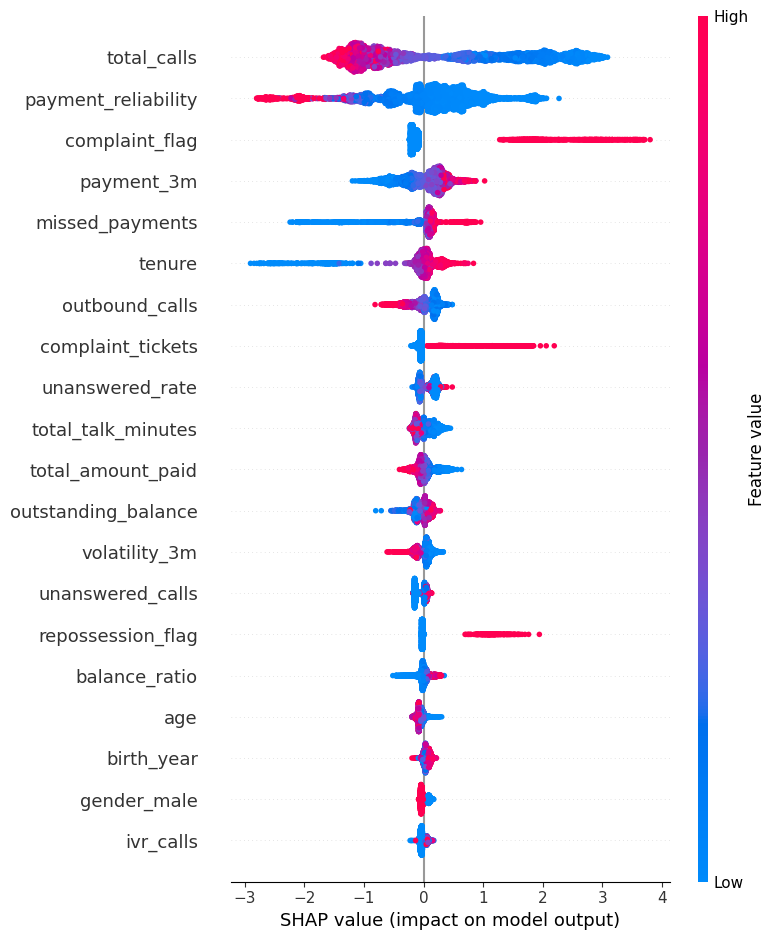

In [132]:
shap.summary_plot(
    shap_values,
    X_test
)

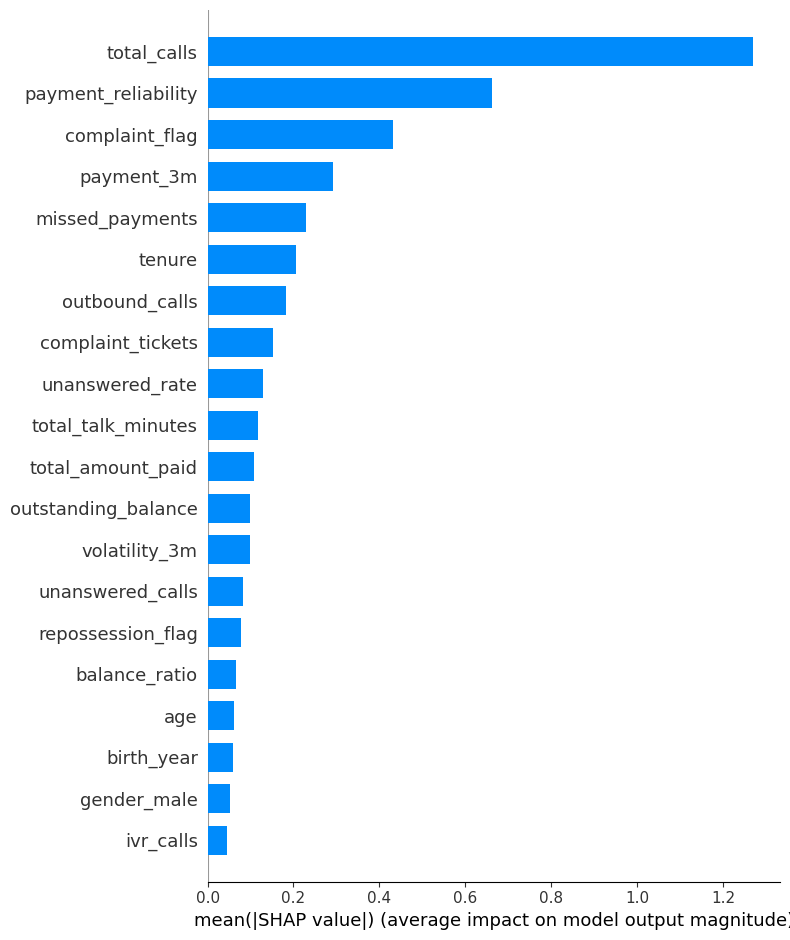

In [133]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

### Extract feature importance as dataframe

In [135]:
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "Importance",
    ascending=False
)

shap_importance.head(10)

,Feature,Importance
12,total_calls,1.269338
24,payment_reliability,0.661537
26,complaint_flag,0.431549
7,payment_3m,0.291825
4,missed_payments,0.229271
0,tenure,0.205709
13,outbound_calls,0.181640
21,complaint_tickets,0.152607
25,unanswered_rate,0.127948
18,total_talk_minutes,0.117128


### Individual customer explanation

In [138]:
import shap

shap.initjs()

In [139]:
customer_index = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[customer_index],
    X_test.iloc[customer_index]
)

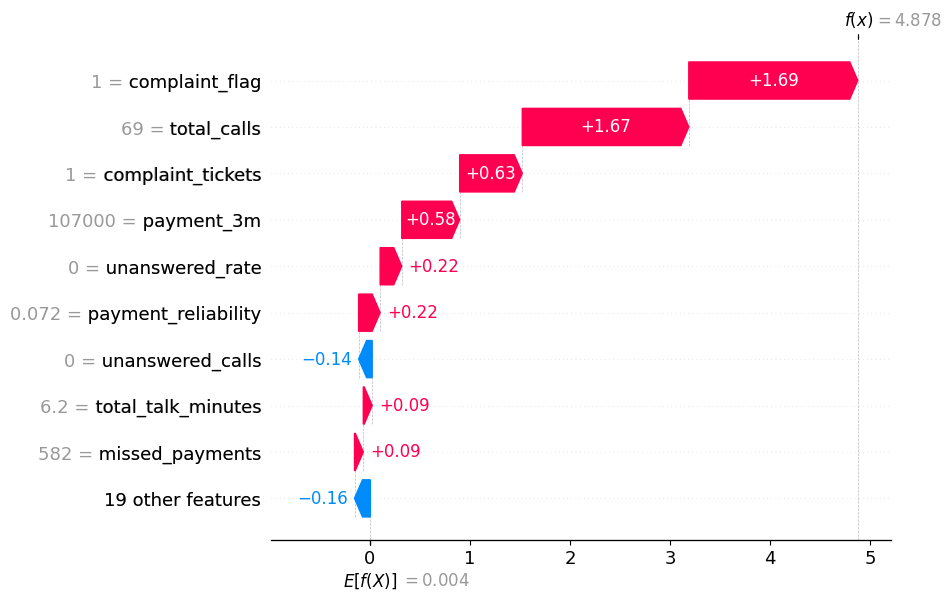

In [140]:
customer_index = 0

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[customer_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[customer_index],
        feature_names=X_test.columns
    )
)

In [144]:
shap_values.shape

(5315, 28)

In [187]:
best_model = models["XGBoost"]

## Generate predictions using final XGBoost model

In [188]:
# Final selected model
best_model = models["XGBoost"]


# Prepare full dataset for prediction
X_full = model_data.drop(
    ['churn', 'customer_id', 'last_paid_month'],
    axis=1
)


# Predict churn probability
churn_probability = best_model.predict_proba(
    X_full
)[:, 1]


# Predict churn class
churn_prediction = best_model.predict(
    X_full
)

###  Create customer risk dataframe

In [189]:
customer_risk = pd.DataFrame({

    "customer_id": model_data["customer_id"],

    "actual_churn": model_data["churn"],

    "churn_probability": churn_probability,

    "predicted_churn": churn_prediction

})


customer_risk.head()

,customer_id,actual_churn,churn_probability,predicted_churn
0,GBEFDJG,1,0.196221,0
1,GBAGFBB,1,0.126827,0
2,GEJGIFG,1,0.592217,1
3,GEEDDAC,1,0.976802,1
4,GBBDGBC,1,0.969303,1


In [190]:
customer_risk.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26575 entries, 0 to 26999
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        26575 non-null  object 
 1   actual_churn       26575 non-null  int64  
 2   churn_probability  26575 non-null  float32
 3   predicted_churn    26575 non-null  int64  
dtypes: float32(1), int64(2), object(1)
memory usage: 934.3+ KB


## Create risk categories

In [192]:
def assign_risk(prob):

    if prob >= 0.70:
        return "High Risk"

    elif prob >= 0.30:
        return "Medium Risk"

    else:
        return "Low Risk"



customer_risk["risk_category"] = (
    customer_risk["churn_probability"]
    .apply(assign_risk)
)
customer_risk["risk_category"].value_counts()

risk_category
High Risk      12137
Low Risk       10904
Medium Risk     3534
Name: count, dtype: int64

### Create final dashboard dataset

In [193]:
dashboard_data = model_data.merge(
    customer_risk[
        [
            "customer_id",
            "churn_probability",
            "predicted_churn",
            "risk_category"
        ]
    ],
    on="customer_id",
    how="left"
)

### Verify dashboard dataset

In [194]:
dashboard_data.shape

(26575, 34)

In [195]:
dashboard_data.columns.tolist()

['customer_id',
 'tenure',
 'total_amount_paid',
 'outstanding_balance',
 'repayment_rate',
 'missed_payments',
 'birth_year',
 'age',
 'payment_3m',
 'avg_payment_3m',
 'payment_trend_3m',
 'volatility_3m',
 'last_paid_month',
 'last_paid_amount',
 'total_calls',
 'outbound_calls',
 'received_calls',
 'unanswered_calls',
 'ivr_calls',
 'csat_calls',
 'total_talk_minutes',
 'repossession_tickets',
 'followup_tickets',
 'complaint_tickets',
 'churn',
 'gender_male',
 'balance_ratio',
 'payment_reliability',
 'unanswered_rate',
 'complaint_flag',
 'repossession_flag',
 'churn_probability',
 'predicted_churn',
 'risk_category']

### Export dashboard data

In [196]:
dashboard_data.to_csv(
    "customer_churn_dashboard_data.csv",
    index=False
)

### Export SHAP results

In [197]:
shap_importance.to_csv(
    "shap_feature_importance.csv",
    index=False
)

### Export model results

In [198]:
results_df.to_csv(
    "model_performance.csv",
    index=False
)